In [ ]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from kerastuner.tuners import RandomSearch

/tmp/ipython-input-2330592690.py:13: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'Colab Notebooks'   XR_ELBOW


In [ ]:
train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"
valid_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
valid_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 4016 images belonging to 2 classes.


In [ ]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 465 images belonging to 2 classes.


In [ ]:
# ⚙️ MODEL BUILDER FUNCTION FOR KERAS TUNER
# ============================================================
def build_model(hp):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Frozen for now (will fine-tune later)

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Option for one or two dense layers
    for i in range(hp.Int('num_dense_layers', 1, 2)):
        x = Dense(
            units=hp.Int(f'units_{i}', min_value=128, max_value=1024, step=128),
            activation='relu'
        )(x)
        x = BatchNormalization()(x)
        x = Dropout(rate=hp.Float(f'dropout_{i}', min_value=0.3, max_value=0.6, step=0.1))(x)

    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice('lr', values=[1e-2, 1e-3, 5e-4, 1e-4, 1e-5])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # increase search space
    executions_per_trial=1,
    directory='xception_tuning_v2',
    project_name='xception_elbow_v2'
)

In [ ]:
tuner.search(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-6)
    ]
)

Trial 10 Complete [00h 12m 39s]
val_accuracy: 0.7763440608978271

Best val_accuracy So Far: 0.7870967984199524
Total elapsed time: 02h 33m 39s


In [ ]:
# ============================================================
# 🏆 BEST HYPERPARAMETERS
# ============================================================
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest Hyperparameters Found:")
for param in ['lr', 'num_dense_layers']:
    print(f" - {param}: {best_hp.get(param)}")
for i in range(best_hp.get('num_dense_layers')):
    print(f" - Dense {i}: units={best_hp.get(f'units_{i}')}, dropout={best_hp.get(f'dropout_{i}')}")


Best Hyperparameters Found:
 - lr: 0.01
 - num_dense_layers: 2
 - Dense 0: units=640, dropout=0.5
 - Dense 1: units=640, dropout=0.4


In [ ]:
model = tuner.hypermodel.build(best_hp)

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-6)
    ]
)

print(f"\n⏱️ Stage 1 Training Time: {(time.time()-start_time)/60:.2f} minutes")

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 105s 753ms/step - accuracy: 0.5565 - loss: 1.2039 - val_accuracy: 0.5806 - val_loss: 1.8199 - learning_rate: 0.0100
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 82s 653ms/step - accuracy: 0.6236 - loss: 0.7181 - val_accuracy: 0.6882 - val_loss: 0.6111 - learning_rate: 0.0100
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 81s 639ms/step - accuracy: 0.6434 - loss: 0.6700 - val_accuracy: 0.7591 - val_loss: 0.4934 - learning_rate: 0.0100
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 81s 641ms/step - accuracy: 0.6519 - loss: 0.6586 - val_accuracy: 0.7011 - val_loss: 0.7228 - learning_rate: 0.0100
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 82s 649ms/step - accuracy: 0.6676 - loss: 0.6394 - val_accuracy: 0.7247 - val_loss: 0.5114 - learning_rate: 0.0100
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 82s 654ms/step - accuracy: 0.6870 - loss: 0.5914 - val_accuracy: 0.7613 - val_loss: 0.4743 - learning_rate: 0.0030
Epoch 7/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 141s 643ms/step - accuracy: 0

In [ ]:
# Unfreeze top 30% of layers
fine_tune_at = int(len(model.layers) * 0.7)
for layer in model.layers[fine_tune_at:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Fine-tune
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.3, patience=2, min_lr=1e-7)
    ]
)

total_time = time.time() - start_time
print(f"\n⏱️ Total Training Time (Fine-Tuned): {total_time/60:.2f} minutes")

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 117s 792ms/step - accuracy: 0.7110 - loss: 0.5472 - val_accuracy: 0.7871 - val_loss: 0.4480 - learning_rate: 1.0000e-05
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 660ms/step - accuracy: 0.7344 - loss: 0.5356 - val_accuracy: 0.8000 - val_loss: 0.4360 - learning_rate: 1.0000e-05
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 676ms/step - accuracy: 0.7343 - loss: 0.5294 - val_accuracy: 0.7935 - val_loss: 0.4318 - learning_rate: 1.0000e-05
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 661ms/step - accuracy: 0.7450 - loss: 0.5068 - val_accuracy: 0.7978 - val_loss: 0.4244 - learning_rate: 1.0000e-05
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 658ms/step - accuracy: 0.7393 - loss: 0.5144 - val_accuracy: 0.7892 - val_loss: 0.4258 - learning_rate: 1.0000e-05
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 678ms/step - accuracy: 0.7378 - loss: 0.5150 - val_accuracy: 0.7892 - val_loss: 0.4238 - learning_rate: 1.0000e-05
Epoch 7/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 6

In [ ]:
save_path = "/content/drive/MyDrive/xception_tuned/xception_best_model_v2.h5"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
model.save(save_path)


In [ ]:
valid_generator.reset()
pred_probs = model.predict(valid_generator)
pred_classes = (pred_probs > 0.5).astype("int32")

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 495ms/step


In [ ]:
true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

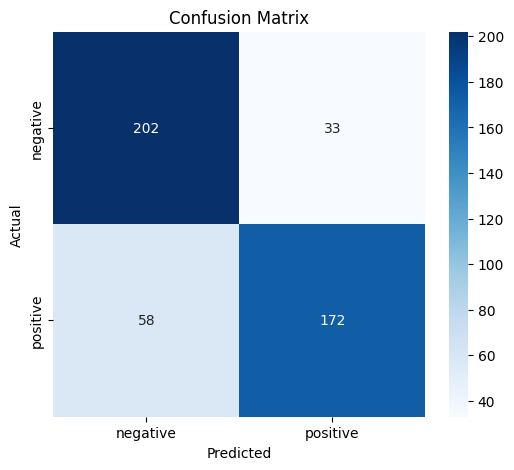

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print("\n📋 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))


📋 Classification Report:

              precision    recall  f1-score   support

    negative       0.78      0.86      0.82       235
    positive       0.84      0.75      0.79       230

    accuracy                           0.80       465
   macro avg       0.81      0.80      0.80       465
weighted avg       0.81      0.80      0.80       465



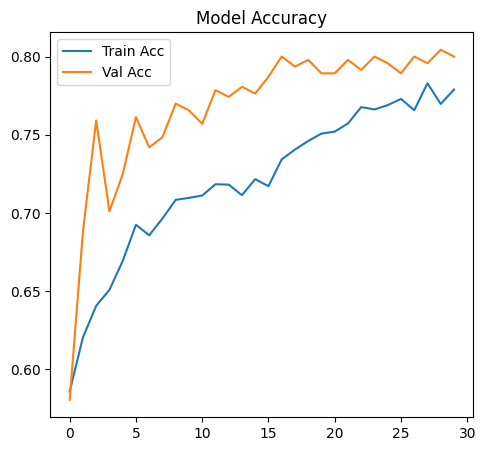

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

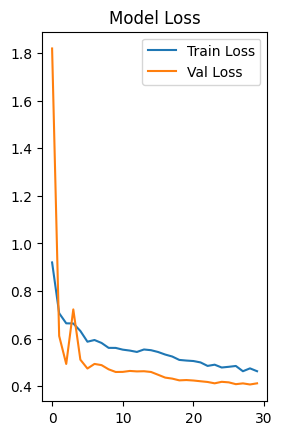

In [ ]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
# ============================================================
# 💾 SAVE MODEL + CALCULATE SIZE + TRAINING TIME
# ============================================================
save_path = "/content/drive/MyDrive/xception_tuned/xception_best_model_v2.h5"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
model.save(save_path)

# Calculate model size
if os.path.exists(save_path):
    model_size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"\n💾 Model saved successfully at: {save_path}")
    print(f"📦 Model Size: {model_size_mb:.2f} MB")
else:
    print("\n⚠️ Model file not found — size calculation skipped.")

# Calculate total training time
total_time = time.time() - start_time
print(f"⏱️ Total Training Time: {total_time/60:.2f} minutes")



💾 Model saved successfully at: /content/drive/MyDrive/xception_tuned/xception_best_model_v2.h5
📦 Model Size: 171.97 MB
⏱️ Total Training Time: 56.00 minutes
